# Feature Selection — Dự báo PM2.5 (horizon 24 giờ)


## Mục tiêu
- Loại các biến gây **đa cộng tuyến / nhiễu** đã được EDA chỉ ra.
- Xếp hạng mức độ “hữu ích” của từng đặc trưng còn lại bằng **Random Forest** và **XGBoost** (chỉ huấn luyện trên **tập train** để không rò rỉ thông tin từ validation/test).
- Chọn **top-K** đặc trưng (mặc định 25, trong khoảng 20–30), có tùy chọn **ép giữ** các lag cốt lõi từ PACF.



## Định nghĩa bài toán (target)

**Horizon:** `FORECAST_HORIZON = 24` (giờ).

Tại thời điểm quan trắc `t`, mục tiêu dự báo là nồng độ PM2.5 tại **`t + 24` giờ**:

$$y(t) = \text{pm25}(t+24)$$

Các dòng cuối chuỗi không đủ 24 giờ tương lai sẽ bị loại (`NaN` sau `shift(-24)`).

**Ghi chú về vector đặc trưng tại \(t\):** Cột `pm25` tại cùng mốc `t` là quan sát đã biết khi bạn đứng tại `t` để dự báo — **không phải leakage** so với \(y = \text{pm25}(t+24)\). Các biến trễ / rolling mô tả thêm lịch sử; mô hình tree sau này có thể dùng cùng logic đặc trưng tại `t` để dự đoán 24h sau.


## Khác biệt với `data/processed/modeling/train_tree.csv` (cũ)

File [`modeling/train_tree.csv`](../data/processed/modeling/train_tree.csv) hiện có cột `pm25` đồng nghĩa với **cùng mốc thời gian** với các đặc trưng (kiểu *nowcasting* / hồi quy đồng bộ), **không** gắn nhãn “PM2.5 sau 24 giờ”.

Notebook này xuất bộ mới dưới [`modeling_fs/`](../data/processed/modeling_fs/) với cột **`target_pm25_h24`** = \(\text{pm25}(t+24)\) để **khớp đề tài dự báo 24h**. Khi báo cáo, hãy nêu rõ đang dùng tập nào để tránh nhầm target.


In [16]:
import json
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import rankdata
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

# --- Cấu hình tái lập (reproducibility) ---
RANDOM_STATE = 42
TOP_K = 25
FORCE_INCLUDE_PACF_LAGS = True  # ép giữ pm25_lag_1, pm25_lag_2, pm25_lag_24 nếu rơi khỏi top-K

EDA_DROP_COLS = [
    "pm1",
    "um003",
    "temperature",
    "relativehumidity",
    "wind_direction_10m",
]

FORCE_LAG_FEATURES = ["pm25_lag_1", "pm25_lag_2", "pm25_lag_24"]

OUT_DIR = Path("../data/processed")
MODELING_FS = OUT_DIR / "modeling_fs"
MODELING_FS.mkdir(parents=True, exist_ok=True)


## Loại biến cố định (theo EDA / TODO)

| Cột loại | Lý do ngắn gọn |
|----------|----------------|
| `pm1`, `um003` | Tương quan cực cao với `pm25` → đa cộng tuyến / rủi ro “gian lận” khi cùng đo hạt. |
| `temperature`, `relativehumidity` (OpenAQ) | Trùng thông tin với Open-Meteo nhưng nhiễu hơn (vi khí hậu cảm biến). |
| `wind_direction_10m` | Biến góc 0–360° không liên tục; đã mã hóa hướng qua `wind_u`, `wind_v`. |

Tham chiếu: [`2_EDA_python.ipynb`](2_EDA_python.ipynb) (heatmap, bảng action plan), [`TODO.md`](../../TODO.md).


In [17]:
import pandas as pd
# Load the chronologically split datasets directly
train_df = pd.read_csv('../data/processed/train_split.csv', parse_dates=['datetime_local'])
val_df = pd.read_csv('../data/processed/val_split.csv', parse_dates=['datetime_local'])
test_df = pd.read_csv('../data/processed/test_split.csv', parse_dates=['datetime_local'])

print(f"Train: {train_df.shape}")
print(f"Val: {val_df.shape}")
print(f"Test: {test_df.shape}")

# Process missing columns and EDA_DROP_COLS
for c in EDA_DROP_COLS:
    if c in train_df.columns:
        train_df = train_df.drop(columns=[c])
    if c in val_df.columns:
        val_df = val_df.drop(columns=[c])
    if c in test_df.columns:
        test_df = test_df.drop(columns=[c])


Train: (6383, 50)
Val: (2128, 50)
Test: (2128, 50)


## Mã hóa `wind_condition` (LabelEncoder, fit chỉ trên train)

`wind_condition` là biến phân loại (Calm / Light / Moderate+). RF/XGB cần số — dùng `LabelEncoder` **fit trên train** rồi `transform` cho val/test để tránh lộ nhãn tương lai vào “từ điển” mã hóa.

*Giai đoạn tiền xử lý đầy đủ (TODO): có thể đổi sang Frequency Encoding nếu nhóm muốn — ở đây giữ đơn giản cho bước ranking.*


In [19]:
le_wind = LabelEncoder()
le_wind.fit(train_df["wind_condition"].astype(str))

def encode_wind(sub):
    sub = sub.copy()
    sub["wind_condition_encoded"] = le_wind.transform(sub["wind_condition"].astype(str))
    return sub.drop(columns=["wind_condition"])

train_df = encode_wind(train_df)
val_df = encode_wind(val_df)
test_df = encode_wind(test_df)

df_enc = pd.concat([train_df, val_df, test_df], axis=0).sort_values("datetime_local").reset_index(drop=True)
feature_cols = [c for c in df_enc.columns if c not in ("datetime_local", "target_pm25_h24")]
print(f"Số đặc trưng ứng viên (sau drop EDA + đã encode gió): {len(feature_cols)}")
feature_cols[:10], "...", feature_cols[-5:]


Số đặc trưng ứng viên (sau drop EDA + đã encode gió): 43


(['pm25',
  'temperature_2m',
  'relative_humidity_2m',
  'precipitation',
  'surface_pressure',
  'wind_speed_10m',
  'boundary_layer_height',
  'hour',
  'day_of_week',
  'month'],
 '...',
 ['wind_v',
  'pm25_diff_1h',
  'pm25_diff_24h',
  'pressure_trend_3h',
  'wind_condition_encoded'])

## Random Forest & XGBoost — Ý nghĩa `feature_importances_`

- **Random Forest:** mức giảm **impurity** (Gini / MSE) trung bình khi cột đó được dùng để tách nút — đặc trưng quan trọng thường có giá trị lớn hơn.
- **XGBoost:** tần suất / cường độ sử dụng đặc trưng theo **gain** trong boosting (đã tổng hợp thành vector `feature_importances_`).

Hai thang đo **không tương đương tuyệt đối** giữa hai mô hình. Ta **chuẩn hóa min–max riêng từng mô hình** trên vector importance của nó, rồi tính **thứ hạng** (rank): rank 1 = quan trọng nhất. **Thứ hạng trung bình** `(rank_rf + rank_xgb) / 2` dùng để chọn top-K — cách này ổn định hơn so với cộng trực tiếp hai importance khác thang.

*Chỉ `fit` trên `X_train`, `y_train`.*

Trong code, `RandomForestRegressor` và `XGBRegressor` dùng `n_jobs=2` và XGBoost `tree_method='hist'` để cân bằng tốc độ và ổn định trên nhiều môi trường (tránh treo khi `n_jobs=-1` trên một số máy). Bạn có thể tăng `n_estimators` hoặc số job nếu máy chủ mạnh hơn.


In [20]:
X_train = train_df[feature_cols]
y_train = train_df["target_pm25_h24"]

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=2,
    max_depth=20,
)
rf.fit(X_train, y_train)

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.08,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=2,
)
xgb.fit(X_train, y_train)

imp_rf = rf.feature_importances_
imp_xgb = xgb.feature_importances_

def minmax_norm(v):
    v = np.asarray(v, dtype=float)
    lo, hi = v.min(), v.max()
    if hi - lo < 1e-12:
        return np.ones_like(v)
    return (v - lo) / (hi - lo)

norm_rf = minmax_norm(imp_rf)
norm_xgb = minmax_norm(imp_xgb)

rank_rf = rankdata(-imp_rf, method="average")
rank_xgb = rankdata(-imp_xgb, method="average")
mean_rank = (rank_rf + rank_xgb) / 2.0

ranking = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "importance_rf": imp_rf,
            "importance_xgb": imp_xgb,
            "norm_importance_rf": norm_rf,
            "norm_importance_xgb": norm_xgb,
            "rank_rf": rank_rf,
            "rank_xgb": rank_xgb,
            "mean_rank": mean_rank,
        }
    )
    .sort_values("mean_rank", ascending=True)
    .reset_index(drop=True)
)

ranking.head(15)


,feature,importance_rf,importance_xgb,norm_importance_rf,norm_importance_xgb,rank_rf,rank_xgb,mean_rank
0,month,0.125513,0.394477,0.622670,1.000000,2.0,1.0,1.5
1,month_cos,0.201368,0.060036,1.000000,0.152192,1.0,2.0,1.5
2,pm25,0.116214,0.038714,0.576415,0.098141,3.0,5.0,4.0
3,pm25_lag_1,0.027653,0.040976,0.135886,0.103873,7.0,4.0,5.5
4,hours_since_last_rain,0.031279,0.023892,0.153920,0.060566,5.0,6.0,5.5
5,pm25_roll_72h_mean,0.032986,0.019075,0.162412,0.048355,4.0,7.0,5.5
6,pm25_roll_6h_mean,0.029669,0.015758,0.145913,0.039946,6.0,13.0,9.5
7,pm25_lag_24,0.019484,0.016924,0.095248,0.042903,14.0,10.0,12.0
8,pm25_lag_48,0.021854,0.014358,0.107036,0.036398,11.0,15.0,13.0
9,pm25_lag_72,0.024514,0.013987,0.120272,0.035457,8.0,18.0,13.0


## Chọn top-K + tùy chọn ép giữ lag PACF

1. Lấy **K** đặc trưng có `mean_rank` **nhỏ nhất** (quan trọng nhất).
2. Nếu `FORCE_INCLUDE_PACF_LAGS`: thêm `pm25_lag_1`, `pm25_lag_2`, `pm25_lag_24` nếu chúng chưa nằm trong danh sách (bảo lưu cơ sở từ ACF/PACF trong EDA).

Kết quả cuối có thể có **nhiều hơn K** cột nếu các lag bị rơi khỏi top-K — đó là hành vi mong muốn theo kế hoạch (“TOP_K + forced”).


In [21]:
ordered = ranking.sort_values("mean_rank", ascending=True)["feature"].tolist()
selected = []
seen = set()
for f in ordered:
    if len(selected) >= TOP_K:
        break
    if f not in seen:
        selected.append(f)
        seen.add(f)

forced_added = []
if FORCE_INCLUDE_PACF_LAGS:
    for f in FORCE_LAG_FEATURES:
        if f not in seen and f in feature_cols:
            selected.append(f)
            seen.add(f)
            forced_added.append(f)

print(f"Top_K = {TOP_K}, số đặc trưng được chọn: {len(selected)}")
if forced_added:
    print("Đã ép thêm (PACF):", forced_added)
selected


Top_K = 25, số đặc trưng được chọn: 26
Đã ép thêm (PACF): ['pm25_lag_2']


['month',
 'month_cos',
 'pm25',
 'pm25_lag_1',
 'hours_since_last_rain',
 'pm25_roll_72h_mean',
 'pm25_roll_6h_mean',
 'pm25_lag_24',
 'pm25_lag_48',
 'pm25_lag_72',
 'pm25_roll_12h_std',
 'wind_u',
 'pm25_roll_72h_std',
 'surface_pressure',
 'wind_v',
 'pm25_roll_48h_std',
 'pm25_roll_24h_mean',
 'pm25_roll_48h_mean',
 'day_of_week',
 'hour_cos',
 'is_dry_season',
 'temperature_2m',
 'relative_humidity_2m',
 'pm25_roll_24h_std',
 'pm25_lag_12',
 'pm25_lag_2']

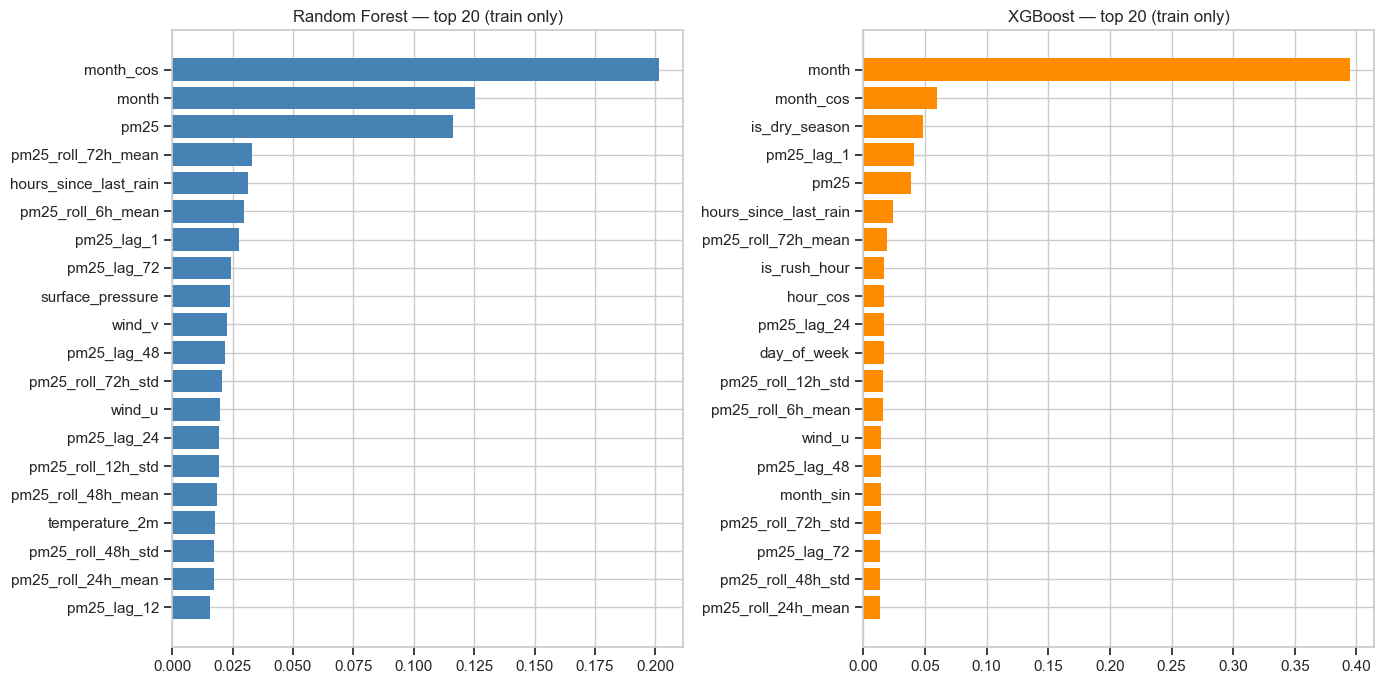

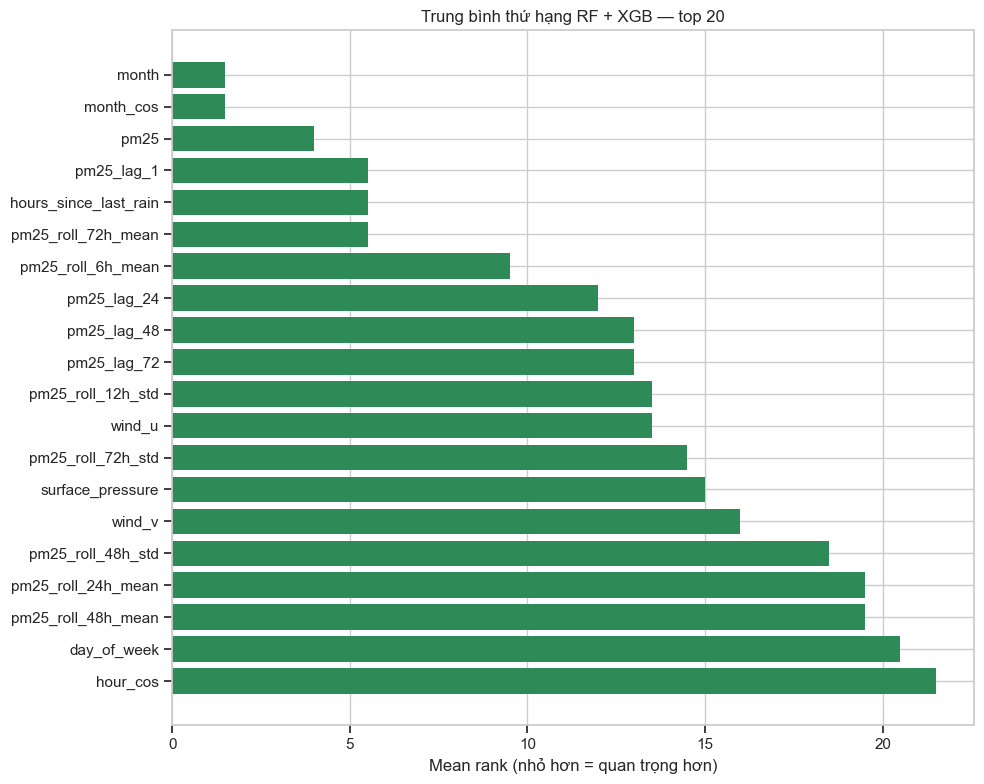

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
top_n = min(20, len(ranking))

sub = ranking.sort_values("importance_rf", ascending=False).head(top_n)
axes[0].barh(sub["feature"][::-1], sub["importance_rf"][::-1], color="steelblue")
axes[0].set_title(f"Random Forest — top {top_n} (train only)")

sub2 = ranking.sort_values("importance_xgb", ascending=False).head(top_n)
axes[1].barh(sub2["feature"][::-1], sub2["importance_xgb"][::-1], color="darkorange")
axes[1].set_title(f"XGBoost — top {top_n} (train only)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
subm = ranking.sort_values("mean_rank", ascending=True).head(top_n)
plt.barh(subm["feature"][::-1], subm["mean_rank"][::-1], color="seagreen")
plt.xlabel("Mean rank (nhỏ hơn = quan trọng hơn)")
plt.title(f"Trung bình thứ hạng RF + XGB — top {top_n}")
plt.tight_layout()
plt.show()


## Xuất file: metadata, bảng importance, CSV cho modeling

- `selected_features.json`: danh sách cột, horizon, top_k, có/không ép lag.
- `feature_importance_ranking.csv`: toàn bộ ứng viên và các cột rank/importance.
- `modeling_fs/train_tree.csv`, `val_tree.csv`, `test_tree.csv`: giữ `datetime_local`, `target_pm25_h24`, và chỉ các đặc trưng đã chọn (đã có `wind_condition_encoded` nếu được chọn).



In [23]:
ranking_path = OUT_DIR / "feature_importance_ranking.csv"
ranking.to_csv(ranking_path, index=False)
print("Đã ghi:", ranking_path)

meta = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "source_file": "../data/processed/train_split.csv",
    "forecast_horizon_hours": 24,
    "top_k": TOP_K,
    "eda_dropped_columns": EDA_DROP_COLS,
    "force_include_pacf_lags": FORCE_INCLUDE_PACF_LAGS,
    "forced_lag_features": forced_added if FORCE_INCLUDE_PACF_LAGS else [],
    "models": {
        "random_forest": "sklearn.ensemble.RandomForestRegressor(n_estimators=200, max_depth=20, n_jobs=2)",
        "xgboost": "xgboost.XGBRegressor(n_estimators=200, max_depth=6, tree_method=hist, n_jobs=2)",
    },
    "split_sizes": {"train": len(train_df), "val": len(val_df), "test": len(test_df)},
    "selected_features": selected,
}

meta_path = OUT_DIR / "selected_features.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print("Đã ghi:", meta_path)

out_cols = ["datetime_local", "target_pm25_h24"] + selected
train_df[out_cols].to_csv(MODELING_FS / "train_tree.csv", index=False)
val_df[out_cols].to_csv(MODELING_FS / "val_tree.csv", index=False)
test_df[out_cols].to_csv(MODELING_FS / "test_tree.csv", index=False)
print("Đã ghi CSV tại:", MODELING_FS.resolve())


Đã ghi: ..\data\processed\feature_importance_ranking.csv
Đã ghi: ..\data\processed\selected_features.json
Đã ghi CSV tại: C:\Users\User\Desktop\Matt Folder\Materials\MyUni\6th Semester\Business Data Analysis\Project\data\processed\modeling_fs
